### Librerias

In [22]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# Nótese el random_split
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
from torch.nn import functional as F


In [23]:
# Tokenizador de GPT-2
from transformers import GPT2Tokenizer, AutoModelForCausalLM

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Hyperparametros

In [24]:
# data hyperparameters
seq_len = 8 # aka context length
stride = 2

# model hyperparameters Cambiamos la dimensionalidad que corresponde a Gpt2
embed_dim = 768

# training hyperparameters
batch_size = 64

In [25]:
# Descargar y tokenizar el texto
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor(tokenizer.encode(text))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (45295 > 1024). Running this sequence through the model will result in indexing errors


## Transición del Modelo: Transferencia y Congelamiento de Pesos (*Freeze Weights*)

Esta será la última vez que trabajaremos con el **Modelo 1**. Aunque su simplicidad resulta didáctica y útil para entender el flujo básico de trabajo, es una arquitectura demasiado elemental para tareas prácticas de modelado de lenguaje.

A partir de aquí, incorporamos dos técnicas fundamentales en el entrenamiento de redes neuronales y modelos de lenguaje:

---

### 1. Copia de Pesos entre Capas (*Weight Transfer*)
Aprenderemos a extraer y transferir los parámetros aprendidos (pesos y sesgos) de una capa específica de un modelo hacia la capa equivalente de una arquitectura distinta o más compleja. Esto nos permite:
* Reutilizar representaciones previamente entrenadas (por ejemplo, la matriz de *embeddings*).
* Inicializar modelos avanzados con conocimiento previo en lugar de comenzar con pesos aleatorios.

---

### 2. Congelamiento de Pesos durante el Entrenamiento (*Layer Freezing*)
El congelamiento de pesos consiste en impedir de forma selectiva que el descenso de gradiente modifique los parámetros de una capa en particular.

* **Mecánica:** Aunque el modelo continúa su entrenamiento global mediante propagación hacia adelante y hacia atrás, desactivamos la optimización para las capas elegidas (`requires_grad = False`).
* **Propósito:** Se bloquean las actualizaciones en las capas congeladas mientras el optimizador concentra el ajuste únicamente en las nuevas capas añadidas o en componentes específicos de la red.

In [26]:
# Crear una clase para el dataset (nota: el agrupamiento en lotes lo hace el DataLoader, no el dataset)
class TokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # Inicializar
    self.inputs  = []
    self.targets = []

    # Secuencias superpuestas de longitud seq_len
    for i in range(0, len(tokens) - seq_len, stride):

      # Obtener tokens y agregarlos a las listas
      self.inputs.append( tokens[i     : i + seq_len])
      self.targets.append(tokens[i + 1 : i + seq_len + 1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]

In [27]:
# ¡Crear una instancia!
token_dataset = TokenDataset(tmTokens, seq_len, stride)

# Calcular los tamaños
train_ratio = 0.9
train_size = int(train_ratio * len(token_dataset))
test_size  = len(token_dataset) - train_size

# Crear subconjuntos de entrenamiento y prueba
train_dataset, test_dataset = random_split(
    token_dataset, [train_size, test_size]
)

# Crear los DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'El conjunto de entrenamiento tiene {train_size:5} secuencias.')
print(f'El conjunto de prueba tiene        {test_size:5} secuencias.')

El conjunto de entrenamiento tiene 20379 secuencias.
El conjunto de prueba tiene         2265 secuencias.


## El modelo

In [28]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # Matriz de embeddings
    self.embedding = nn.Embedding(tokenizer.vocab_size, embed_dim)

    # Activación no lineal y proyección lineal hacia el vocabulario
    self.gelu = nn.GELU()
    self.finalLinear = nn.Linear(embed_dim, tokenizer.vocab_size, bias=False)

  def forward(self, tokx):
    # Propagación hacia adelante
    x = self.embedding(tokx)
    x = self.gelu(x)
    x = self.finalLinear(x)

    # Retornar log-softmax a lo largo del eje del vocabulario
    return F.log_softmax(x, dim=-1)

  def generate(self, tokx, n_new_tokens=30):
    for _ in range(n_new_tokens):
      # Propagación hacia adelante
      x = self(tokx)
      # Conservar solo el último token
      x = x[:, -1, :]
      # Obtener probabilidades reales
      probs = torch.exp(x)
      # Muestreo probabilístico multinomial
      tokx_next = torch.multinomial(probs, num_samples=1)
      # Concatenar el nuevo token a la secuencia
      tokx = torch.cat((tokx, tokx_next), dim=1)
    return tokx

## Importar el otro modelo

In [29]:
# Importar el modelo GPT-2 small
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [30]:
model = Model() # intancia del modelo uno

In [31]:
# Comprobar que las dimensiones coincidan
print(f'Embedding de mi modelo:    {model.embedding.weight.shape}')
print(f'Embedding del modelo GPT-2: {gpt2.transformer.wte.weight.shape}')

Embedding de mi modelo:    torch.Size([50257, 768])
Embedding del modelo GPT-2: torch.Size([50257, 768])


In [32]:
# Y copiar los pesos y remplazar
model.embedding.weight.data = gpt2.transformer.wte.weight.data

In [33]:
# Comprobar igualdad (debe dar un tensor lleno de ceros) si los restamos (no es la matriz completa solo la 1 por ejemplo [0])
model.embedding.weight[0] - gpt2.transformer.wte.weight[0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [34]:
# model.embedding.weight[12] - gpt2.transformer.wte.weight[12] si lo colocamos asi seria matriz igual contra matriz igual no puede ser [0] - [12] por ejemplo

## Entrenar los datos con los embeddings congelados

In [35]:
# no entranamos GPT ya esta entrenado - y la matriz de embeddings del modelo uno tampoco porque la tomamos del modelo de GPT

### Clarificación Conceptual: Rol de GPT-2 y Congelamiento de Embeddings

Es importante dejar clara la distinción en este flujo de trabajo:

* **No estamos entrenando el modelo GPT-2:**  
  GPT-2 ya cuenta con un preentrenamiento completo a gran escala[cite: 1, 2]. No se actualizan sus capas transformadoras ni sus bloques de atención.

* **¿Qué hacemos con el Modelo 1?**  
  Entrenamos la arquitectura del **Modelo 1**, pero **no entrenamos su matriz de *embeddings***[cite: 1, 2]:
  1. **Transferencia de pesos:** Se extraen los vectores latentes de la matriz de *embeddings* preentrenada de GPT-2 y se copian directamente en la capa `self.embedding` del Modelo 1.
  2. **Congelamiento selectivo (*Freezing*):** Se bloquea la actualización de estos parámetros asignando `requires_grad = False`.

* **Efecto durante el descenso de gradiente:**  
  Los *embeddings* semánticos de GPT-2 se mantienen fijos como representaciones estáticas de entrada, y el optimizador actualiza exclusivamente las capas restantes (como la proyección lineal final) para adaptarse a los datos de la tarea[cite: 1, 2].

In [36]:
# Activar esto si estás trabajando en el ejercicio 3
this_is_exercise3 = False # variable del ejercicio True para activarla la cambiamos para el ejercicio 4 a False para desactivarla

if this_is_exercise3:

  # Estado inicial
  print(model.embedding.weight.requires_grad) # significa que este sera entrenado

  # Desactivarlo
  model.embedding.weight.requires_grad = False # significa que este no sera entrenado

  # Confirmar
  print(model.embedding.weight.requires_grad)

## Entrenarlo

In [37]:
# Mover el modelo a la GPU
model = model.to(device)

In [38]:
# Crear la función de pérdida y el optimizador
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

In [39]:
num_epochs = 10

# Inicializar listas de pérdidas
train_loss = []
test_loss = []

for epoch in range(num_epochs):

  # Inicializar pérdida por época
  epoch_loss = 0

  # Iterar sobre los lotes del dataloader de entrenamiento
  for X, y in train_dataloader:

    # Mover datos a la GPU
    X, y = X.to(device), y.to(device)

    # Reiniciar gradientes acumulados
    model.zero_grad()

    # Propagación hacia adelante
    log_probs = model(X)

    # Calcular la pérdida aplanando las dimensiones: [batch * seq_len, vocab_size] y [batch * seq_len]
    log_probs_flat = log_probs.view(-1, log_probs.shape[-1])
    y_flat = y.view(-1)
    loss = loss_function(log_probs_flat, y_flat)

    # Retropropagación y paso del optimizador
    loss.backward()
    optimizer.step()

    # Acumular la pérdida por época
    epoch_loss += loss.item()
  # Fin del bucle de lotes de entrenamiento

  # Evaluar el modelo con el conjunto de prueba
  with torch.no_grad():
    testloss = 0  # Reiniciar la pérdida de prueba
    for X, y in test_dataloader:
      X, y = X.to(device), y.to(device)             # Mover datos a la GPU
      out = model(X)                                # Propagación hacia adelante
      out_flat = out.reshape(-1, out.shape[-1])     # Aplanar salida
      thisloss = loss_function(out_flat, y.view(-1)) # Calcular pérdida
      testloss += thisloss.item()                   # Acumular a la pérdida de prueba

  # Promediar la pérdida dividiendo por el número de lotes
  train_loss.append(epoch_loss / len(train_dataloader))
  test_loss.append(testloss / len(test_dataloader))

  # Mostrar progreso por época
  print(f'Época {epoch+1:2}, pérdida entrenamiento: {epoch_loss / len(train_dataloader):.4f}, pérdida prueba: {testloss / len(test_dataloader):.4f}')

Época  1, pérdida entrenamiento: 6.9624, pérdida prueba: 5.2197
Época  2, pérdida entrenamiento: 4.6518, pérdida prueba: 4.3962
Época  3, pérdida entrenamiento: 3.9300, pérdida prueba: 3.8857
Época  4, pérdida entrenamiento: 3.4822, pérdida prueba: 3.5758
Época  5, pérdida entrenamiento: 3.2609, pérdida prueba: 3.4031
Época  6, pérdida entrenamiento: 3.1620, pérdida prueba: 3.3039
Época  7, pérdida entrenamiento: 3.1131, pérdida prueba: 3.2470
Época  8, pérdida entrenamiento: 3.0876, pérdida prueba: 3.2091
Época  9, pérdida entrenamiento: 3.0738, pérdida prueba: 3.1873
Época 10, pérdida entrenamiento: 3.0644, pérdida prueba: 3.1722


### Comparativa Experimental: Embeddings Congelados vs. Ajuste Fino (*Fine-Tuning*)

Para evaluar el impacto de las representaciones preentrenadas frente al entrenamiento desde cero, establecemos el siguiente diseño experimental:

* **Origen de los *embeddings*:**  
  En ambos casos, la matriz de *embeddings* del Modelo 1 se inicializa copiando los pesos ya aprendidos de GPT-2, evitando arrancar con valores aleatorios (*random initialization*)[cite: 1, 2].

* **Las dos condiciones de prueba:**
  1. **Condición A (Pesos congelados - *Frozen Embeddings*):**  
     Se bloquea el gradiente en la matriz copiada (`param.requires_grad = False`). Los vectores de GPT-2 permanecen intactos y estáticos; el optimizador únicamente ajusta la proyección lineal final[cite: 1, 2].
  2. **Condición B (Pesos entrenables - *Fine-Tuning*):**  
     Se permite que el descenso de gradiente actualice también los pesos copiados (`param.requires_grad = True`)[cite: 1, 2]. La matriz parte del conocimiento lingüístico de GPT-2, pero se adapta libremente a la distribución del nuevo texto[cite: 1, 2].

* **Objetivo visual:**  
  Entrenar ambos modelos bajo los mismos hiperparámetros y graficar las dos curvas de pérdida (*Train Loss* y *Test Loss*) lado a lado en subplots (`plt.subplots(1, 2)`). Esto permite contrastar directamente la velocidad de convergencia, la estabilidad del error y el efecto de congelar representaciones frente a recalibrarlas.

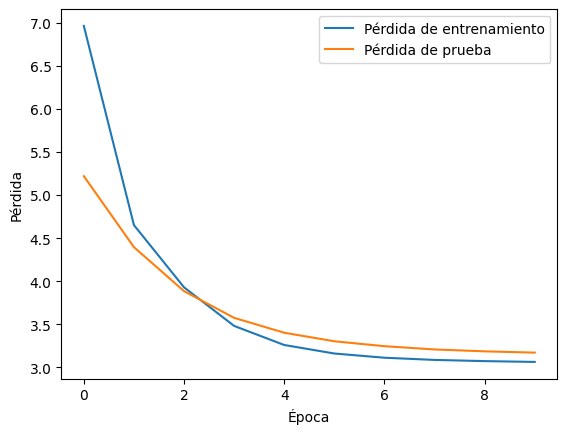

In [40]:
# Graficar las curvas de pérdida
plt.plot(train_loss, label='Pérdida de entrenamiento')
plt.plot(test_loss, label='Pérdida de prueba')

plt.legend()
plt.gca().set(xlabel='Época', ylabel='Pérdida')
plt.show()

## Análisis Crítico: Cuándo Congelar Pesos (*Freeze Weights*) y Cuándo No

El congelamiento de capas (*layer freezing*) y la transferencia de conocimiento (*transfer learning*) son prácticas estándar en Deep Learning, popularizadas principalmente en visión por computadora (CNNs sobre ImageNet). Sin embargo, su conveniencia no es absoluta: depende críticamente del tamaño del modelo, el volumen del corpus y la distribución de los datos.

---

### 1. El escenario ideal para congelar pesos
Congelar representaciones preentrenadas funciona de manera óptima cuando:
* **El modelo es muy grande y el conjunto de datos es pequeño:** Previene que los millones de parámetros libres memoricen las pocas muestras disponibles (*overfitting* severo).
* **Los datos de destino son semánticamente similares a los originales:** Las características de bajo nivel (bordes/texturas en CNNs, o sintaxis común en NLP) son plenamente reutilizables sin necesidad de recalibración.

---

### 2. El riesgo de congelar en arquitecturas simples y datos específicos
En el caso del **Modelo 1**, congelar los pesos de GPT-2 no siempre garantiza una ventaja e incluso puede perjudicar el rendimiento por varias razones:

* **Poca complejidad interna:** Al tener únicamente una capa lineal tras los *embeddings*, el modelo no cuenta con suficientes parámetros libres para adaptar representaciones rígidas externas a la nueva tarea.
* **Sesgo del dominio de origen:** Si el corpus actual difiere del texto con el que se entrenó GPT-2 (WebText), los vectores congelados imponen una geometría en el espacio latente que no refleja fielmente las coocurrencias del nuevo vocabulario.
* **Impedimento del aprendizaje de características clave:** Si se dispone de suficientes tokens, congelar los *embeddings* actúa como una restricción artificial excesiva que impide que la red proyecte las palabras hacia un espacio adaptado al contexto directo del dataset.

Por esta razón, en este tipo de arquitecturas elementales, entrenar los *embeddings* desde cero o permitirles un ajuste fino (*fine-tuning*) suele permitir que el Modelo 1 aprenda mejor las regularidades estadísticas del texto que manteniéndolos estrictamente congelados.